# Week 5 Day 3 — Signal Construction

Converts demeaned residuals into a tradeable z-score signal.

```
z_t = (residual_t  −  rolling_mean_60d) / rolling_std_60d
```

| z-score | interpretation | action |
|---------|---------------|--------|
| z > +2.0 | cheap by 2σ | buy |
| z < −2.0 | rich by 2σ  | sell |
| z → 0   | back to average | exit |

Output: `data/processed/richness_signal.parquet`  
Columns: `date, maturity, residual_bps, rolling_mean, rolling_std, z_score`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
%matplotlib inline

from termstructure.signals.richness import compute_zscore_signal

## 1. Compute signal

In [2]:
sig = compute_zscore_signal(window=60, min_periods=30)
print(f'\nShape : {sig.shape}')
print(f'Dates : {sig["date"].min().date()} -> {sig["date"].max().date()}')
sig.head(8)

Saved 99,190 rows -> C:\Users\aarna\Documents\termstructure\data\processed\richness_signal.parquet
Signal at |z| > 2:  4,696 long  4,765 short  (9.5% of all obs)

Shape : (99190, 6)
Dates : 1971-09-27 -> 2024-12-31


,date,maturity,residual_bps,rolling_mean,rolling_std,z_score
0,1971-09-27,1,-0.003354,-0.003218,0.001376,-0.098744
1,1971-09-27,2,0.084717,0.082160,0.021180,0.120729
2,1971-09-27,3,-0.268919,-0.266860,0.022738,-0.090524
3,1971-09-27,5,0.227000,0.235977,0.032343,-0.277539
4,1971-09-27,7,0.430157,0.425140,0.021975,0.228284
5,1971-09-27,10,-0.172918,-0.180215,0.061907,0.117879
6,1971-09-28,1,-0.003539,-0.003228,0.001355,-0.229069
7,1971-09-28,2,0.081781,0.082148,0.020825,-0.017631


## 2. Spot-check

Pick one maturity, take one row, recompute the z-score by hand from the
preceding 60 residuals, and verify it matches.

In [3]:
residuals = pd.read_parquet('../data/processed/bond_residuals.parquet')
residuals['date'] = pd.to_datetime(residuals['date'])
pivot = residuals.pivot(index='date', columns='maturity', values='residual_bps').sort_index()

MAT = 10
s = pivot[MAT].dropna()
check_date = s.index[90]   # row 90 — well inside the 60-day window

window_vals = s.loc[:check_date].iloc[-60:]   # last 60 rows up to and including check_date
manual_z    = (s[check_date] - window_vals.mean()) / window_vals.std()

stored = sig[(sig['maturity'] == MAT) & (sig['date'] == check_date)]['z_score'].iloc[0]

print(f'Date          : {check_date.date()}')
print(f'Residual      : {s[check_date]:.4f} bp')
print(f'Window mean   : {window_vals.mean():.4f} bp')
print(f'Window std    : {window_vals.std():.4f} bp')
print(f'Manual z      : {manual_z:.6f}')
print(f'Stored z      : {stored:.6f}')
print(f'Match         : {abs(manual_z - stored) < 1e-6}')

Date          : 1971-12-28
Residual      : -0.1997 bp
Window mean   : -0.1691 bp
Window std    : 0.0509 bp
Manual z      : -0.600574
Stored z      : -0.600574
Match         : True


## 3. Signal summary by maturity

If the z-score is properly standardised:
- `z_mean` should be near 0 at every maturity
- `z_std` should be near 1 (slightly below due to autocorrelation)
- Signal fires ~5% of the time per tail → ~10% total at |z| > 2

In [4]:
summary = (
    sig.groupby('maturity')
    .apply(lambda d: pd.Series({
        'n_obs':   len(d),
        'z_mean':  d['z_score'].mean(),
        'z_std':   d['z_score'].std(),
        'n_long':  (d['z_score'] >  2.0).sum(),
        'n_short': (d['z_score'] < -2.0).sum(),
        'pct_signal': (d['z_score'].abs() > 2.0).mean(),
    }), include_groups=False)
    .round(3)
)
summary

,n_obs,z_mean,z_std,n_long,n_short,pct_signal
maturity,,,,,,
1,13286.0,-0.015,1.269,540.0,683.0,0.092
2,13286.0,0.001,1.276,701.0,561.0,0.095
3,13286.0,0.021,1.260,593.0,646.0,0.093
5,13286.0,-0.037,1.270,583.0,667.0,0.094
7,13286.0,-0.009,1.252,647.0,578.0,0.092
10,13286.0,-0.007,1.269,672.0,588.0,0.095
20,10805.0,-0.001,1.309,523.0,611.0,0.105
30,8669.0,-0.009,1.280,437.0,431.0,0.100


## 4. Z-score time series at benchmark maturities

The signal should look like stationary noise crossing the ±2 thresholds
occasionally. Long clusters of extreme z-scores indicate a regime (e.g. 2008,
2020) where the 60-day window is temporarily slower to adapt.

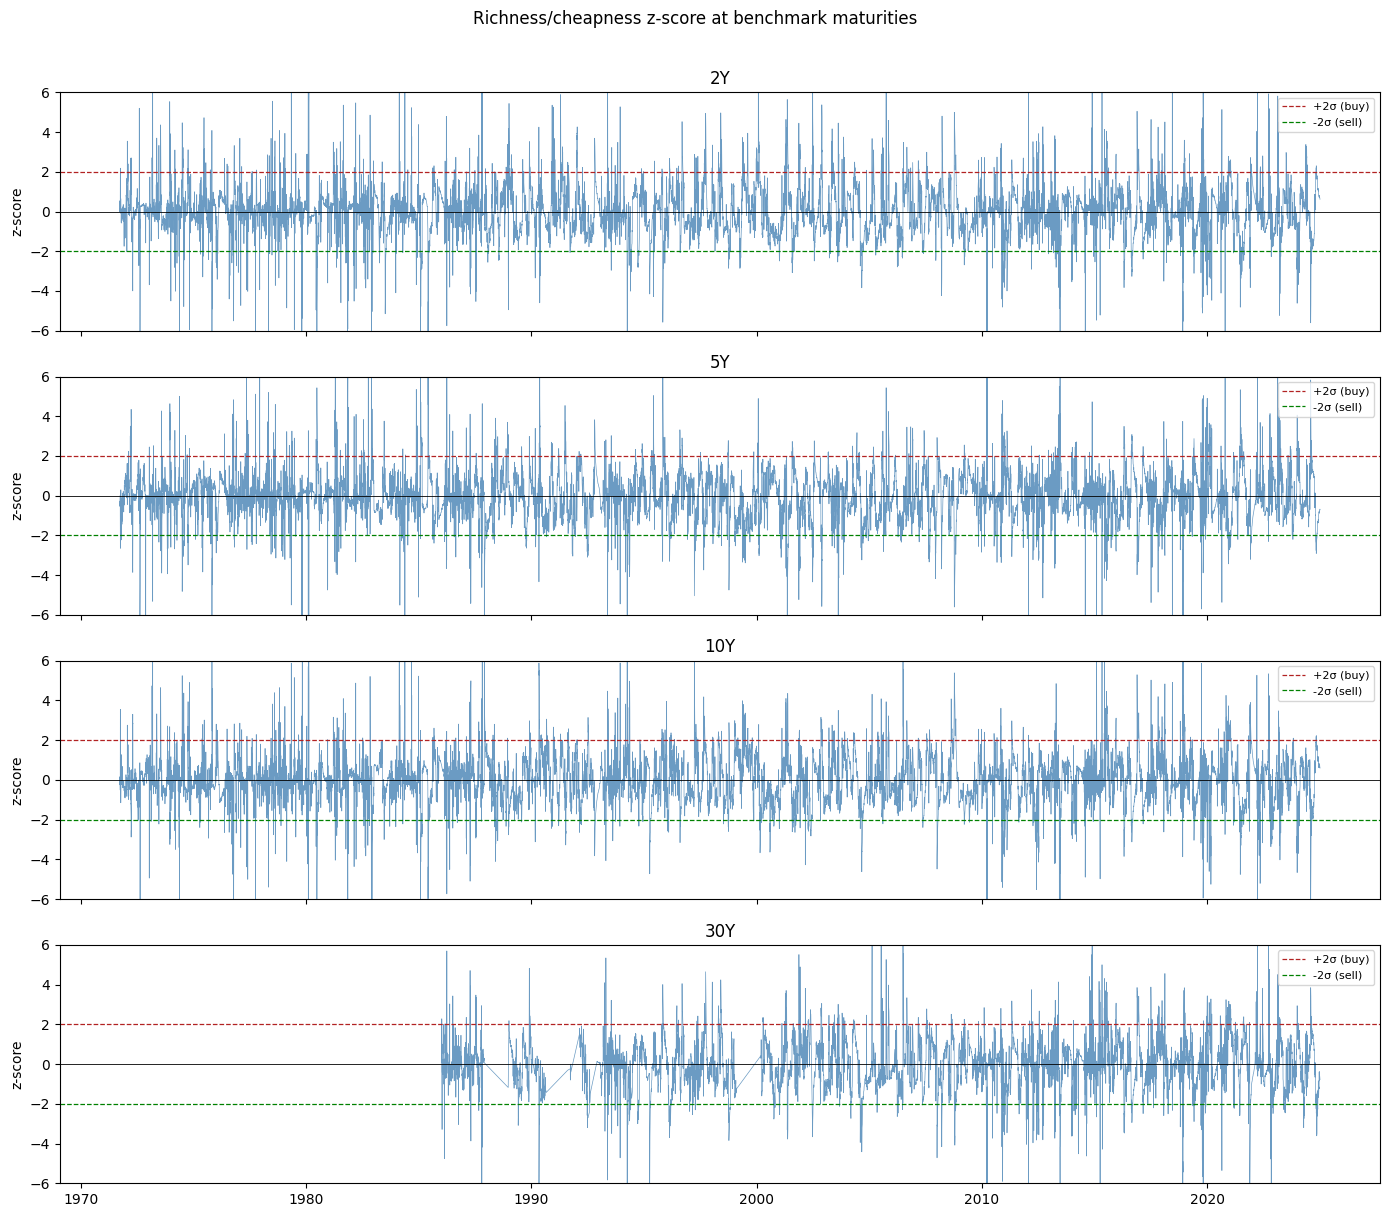

In [5]:
BENCHMARKS = [2, 5, 10, 30]
pivot_z = sig.pivot(index='date', columns='maturity', values='z_score')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, mat in zip(axes, BENCHMARKS):
    z = pivot_z[mat].dropna()
    ax.plot(z.index, z.values, lw=0.5, color='steelblue', alpha=0.8)
    ax.axhline( 2.0, color='firebrick', lw=0.9, ls='--', label='+2σ (buy)')
    ax.axhline(-2.0, color='green',     lw=0.9, ls='--', label='-2σ (sell)')
    ax.axhline( 0.0, color='black',     lw=0.6)
    ax.set_ylabel('z-score')
    ax.set_title(f'{mat}Y')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(-6, 6)

fig.suptitle('Richness/cheapness z-score at benchmark maturities', y=1.01)
plt.tight_layout()
plt.savefig('data/week5_day3_zscore_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Z-score distribution vs standard normal

We expect:
- Near-normal shape (the residuals are near-normal after the outlier filter)
- Slight fat tails (excess kurtosis inherited from the residuals)
- The ±2σ threshold cuts at approximately the right fraction of observations

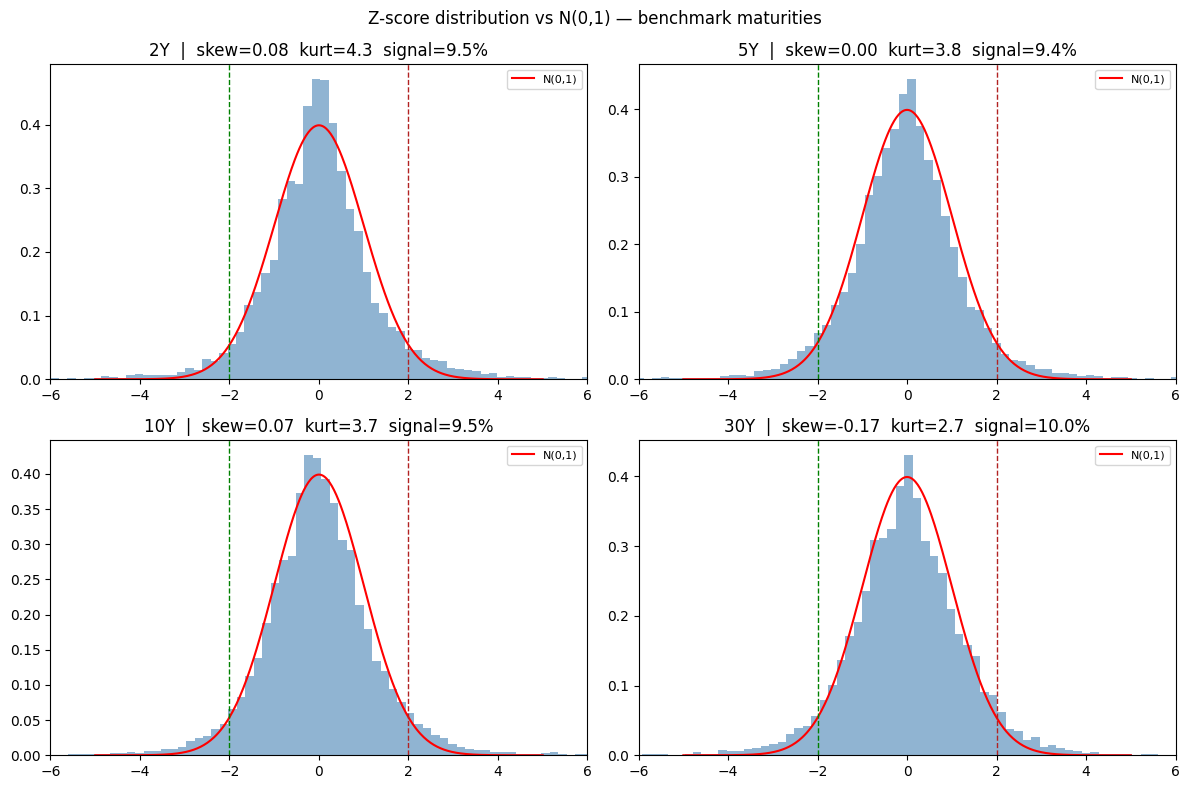

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
x = np.linspace(-5, 5, 400)

for ax, mat in zip(axes, BENCHMARKS):
    z = pivot_z[mat].dropna()
    ax.hist(z, bins=80, density=True, color='steelblue', alpha=0.6)
    ax.plot(x, norm.pdf(x), 'r-', lw=1.5, label='N(0,1)')
    ax.axvline( 2, color='firebrick', lw=1, ls='--')
    ax.axvline(-2, color='green',     lw=1, ls='--')
    pct = (z.abs() > 2).mean()
    ax.set_title(f'{mat}Y  |  skew={z.skew():.2f}  kurt={z.kurt():.1f}  signal={pct:.1%}')
    ax.set_xlim(-6, 6)
    ax.legend(fontsize=8)

fig.suptitle('Z-score distribution vs N(0,1) — benchmark maturities')
plt.tight_layout()
plt.savefig('data/week5_day3_zdist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Current signal snapshot

What is the signal saying right now — which maturities are cheap or rich?

Signal as of 2024-12-31

          residual_bps  rolling_mean  rolling_std  z_score
maturity                                                  
1                0.009         0.039        0.046   -0.646
2               -0.100        -0.388        0.465    0.619
3               -0.002         0.151        0.307   -0.498
5                0.366         0.791        0.616   -0.691
7               -0.287        -0.174        0.253   -0.446
10              -1.014        -1.527        0.863    0.595
20               1.951         1.269        1.080    0.631
30              -7.588        -1.750        7.472   -0.781


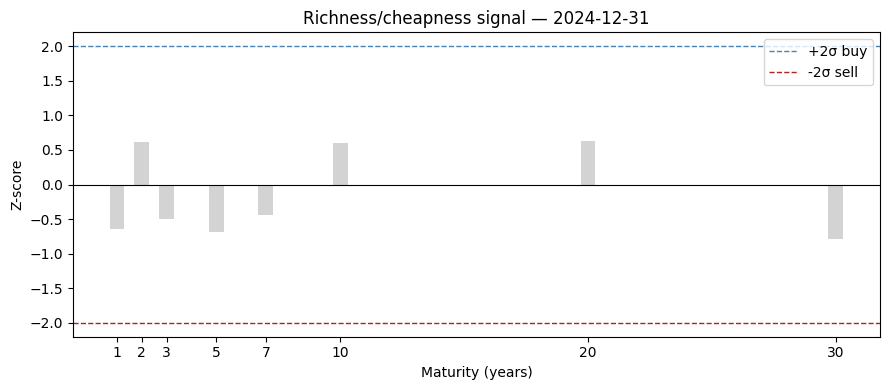

In [7]:
latest_date = sig['date'].max()
latest = sig[sig['date'] == latest_date].set_index('maturity').sort_index()

print(f'Signal as of {latest_date.date()}\n')
print(latest[['residual_bps', 'rolling_mean', 'rolling_std', 'z_score']].round(3))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [
    'firebrick' if z < -2 else 'steelblue' if z > 2 else 'lightgrey'
    for z in latest['z_score']
]
ax.bar(latest.index, latest['z_score'], color=colors, width=0.6)
ax.axhline( 2, color='steelblue', lw=1, ls='--', label='+2σ buy')
ax.axhline(-2, color='firebrick', lw=1, ls='--', label='-2σ sell')
ax.axhline( 0, color='black',     lw=0.8)
ax.set_xticks(latest.index)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Z-score')
ax.set_title(f'Richness/cheapness signal — {latest_date.date()}')
ax.legend()
plt.tight_layout()
plt.savefig('data/week5_day3_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()